# Modulation in Synthetic Earthquake Catalogs

We build synthetic earthquakes catalogs by sampling a heterogeneous Poisson process with the following rate $r(t)$:

$$ r(t) = r_0 \exp \left(\dfrac{S(t)}{a \sigma_n}\right) $$

This model is consistent with the predictions of the rate- and state-dependent friction model (see Heimisson and Avouac, 2020). The parameters are:
- $r_0$: background seismicity rate,
- $S(t)$: tidal Coulomb stress,
- $a$: rate-dependence constitutive frictional parameter
- $\sigma_n$: effective normal stress.

When $S(t)$ is taken from a tidal stress model, this simple synthetic test allows us to explore two important, and sometimes overlooked, features of the tidal modulation of seismicity:
- $S(t)$ is a complex, non-harmonic function of time rather than a simple sinusoid,
- the relationship between seismicity and forcing is non-linear.


References
----------
Heimisson, E. R., & Avouac, J. P. (2020). Analytical prediction of seismicity rate due to tides and other oscillating stresses. Geophysical Research Letters, 47(23), e2020GL090827.

In [30]:
%reload_ext autoreload
%autoreload 2

import os
import sys
HOME = os.path.expanduser("~")
ROOT = os.path.join(HOME, "")

import colorcet as cc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
import seistides
import seistides.schuster

from scipy.signal import hilbert, resample_poly
from scipy.signal.windows import tukey
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from tqdm import tqdm

plt.rcParams["savefig.dpi"] = 200
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["patch.force_edgecolor"] = False
pd.set_option('display.width', 1000)

In [31]:
def rs_modulation(S, a_sigma_n = 10.e3):
    """Rate-and-state-friction-predicted seismicity modulation.

    Parameters
    ----------
    S : numpy.ndarray
        Time series of tidal Coulomb stress.
    a_sigma_n : float
        Product of constitutive parameter `a` with effective normal stress `sigma_n`, in Pa.

    Returns
    -------
    numpy.ndarray
        The modulation term `np.exp(S / a_sigma_n)`.
    """
    return np.exp(S / a_sigma_n)

In [32]:
PATH_DATA = "data"
TIDAL_STRESS_BASENAME = "tidal_stresses"
REGION = "fault_zone" # this doesn't really matter for the synthetic tests, we just want to use realistic tidal stresses

In [33]:
scalar_map_phase = ScalarMappable(
    norm=Normalize(vmin=-np.pi, vmax=+np.pi), cmap="twilight_shifted"
)

In [34]:
cbar_tick_loc = [-np.pi, -np.pi/2., 0., np.pi/2., np.pi]
cbar_tick_lab = [r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"]

## Test 1: Sinusoidal forcing

First, check that the Schuster test works well for a simple (but unrealistic) sinusoidal forcing. 

In [35]:
def generate_nhpp_counts(rates, dt):
    """
    Generates event counts for each time bin in a discrete time series.
    
    Parameters:
        rates (array-like): Time series of rates lambda(t).
        dt (float): Time step duration.
        
    Returns:
        np.ndarray: Binned event counts (same length as rates).
    """
    rates = np.asarray(rates)
    # Expected events per bin = lambda(t) * dt
    mean_events_per_bin = rates * dt
    
    # Vectorized Poisson sampling for each time step
    return np.random.poisson(mean_events_per_bin)

def counts_to_timestamps(counts, dt):
    timestamps = []
    for step, count in enumerate(counts):
        if count > 0:
            # Randomly place events within the [step * dt, (step + 1) * dt] window
            step_times = step * dt + np.random.uniform(0, dt, size=count)
            timestamps.extend(np.sort(step_times))
    return np.array(timestamps)


In [36]:
# --------------------------
#    experiment parameters
# --------------------------
R_0 = 10. # in number of events per day (try R_0=1 to challenge the measurement methods)
T = 0.5 # period in days
AMP = 1.e3 # amplitude of tidal stress (Pa)
A_SIGMA_N = 5.e3 # sensitivity to stress (/Pa)

In [37]:
SAMPLING_TIME_DAYS = 0.01
DURATION_DAYS = 1200

# generate the tidal stress time series and the event rate time series
time = np.arange(0, DURATION_DAYS, SAMPLING_TIME_DAYS)
forcing = AMP * np.cos(2. * np.pi * time / T)
rates = R_0 * rs_modulation(forcing, a_sigma_n=A_SIGMA_N)

# generate a stochastic realization of the nonhomohegeneous poisson process
np.random.seed(42)
event_counts = generate_nhpp_counts(rates, SAMPLING_TIME_DAYS)
# convert the event count into actual event times
event_times = counts_to_timestamps(event_counts, SAMPLING_TIME_DAYS)

In [38]:
##
# make sure that catalog follows expected seismicity vs forcing relationship
bins = np.linspace(forcing.min(), forcing.max(), 10)
bin_membership = np.digitize(forcing, bins=bins)

forcing_midbins = (bins[1:] + bins[:-1]) / 2.
mean_ec = np.zeros(len(forcing_midbins))

for i in range(1, len(bins)):
    sel = bin_membership == i
    forcing_bin = (bins[i-1] + bins[i]) / 2.
    mean_ec[i - 1] = np.mean(event_counts[sel])

ref = np.abs(forcing_midbins - 0.).argmin()


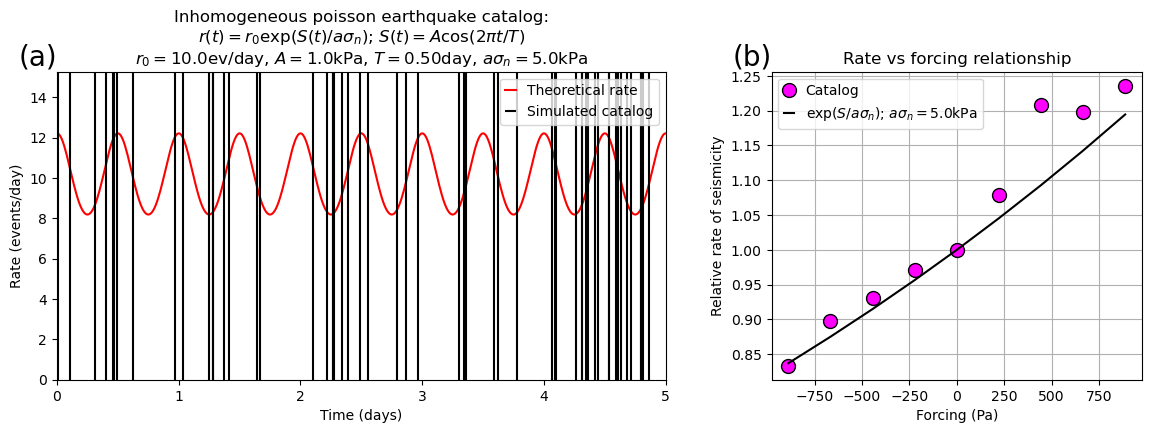

In [39]:
fig = plt.figure("synthetic_catalog", figsize=(14, 4))
gs = fig.add_gridspec(ncols=5, wspace=0.80)
ax1 = fig.add_subplot(gs[:3])
ax1.plot(time, rates, 'r-', label=r'Theoretical rate')
ax1.eventplot(event_times, lineoffsets=0., linelengths=2. * 1.25 * np.exp(AMP / A_SIGMA_N) * R_0, color="k", label="Simulated catalog")
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Rate (events/day)')
title = r"$r(t) = r_0 \exp(S(t) / a \sigma_n)$; $S(t) = A \cos(2\pi t / T)$""\n"r"$r_0=$"f"{R_0:.1f}ev/day, "r"$A=$"f"{AMP/1.e3:.1f}kPa, "r"$T=$"f"{T:.2f}day, "r"$a \sigma_n=$"f"{A_SIGMA_N/1.e3:.1f}kPa"
ax1.set_title('Inhomogeneous poisson earthquake catalog:\n' + title)
ax1.set_xlim(0, 5)
ax1.set_ylim(0., 1.25 * np.exp(AMP / A_SIGMA_N) * R_0)

ax2 = fig.add_subplot(gs[3:])
ax2.plot(forcing_midbins, mean_ec / mean_ec[ref], marker="o", ls="", markeredgecolor="k", markersize=10, color="magenta", label="Catalog")
ax2.plot(forcing_midbins, rs_modulation(forcing_midbins, a_sigma_n=A_SIGMA_N), color="k", label=r"$\exp(S / a \sigma_n)$; $a \sigma_n=$"f"{A_SIGMA_N/1.e3:.1f}kPa")
ax2.set_xlabel("Forcing (Pa)")
ax2.set_ylabel("Relative rate of seismicity")
ax2.grid()
ax2.set_title("Rate vs forcing relationship")

for i, ax in enumerate([ax1, ax2]):
    ax.legend(handlelength=0.75)
    ax.text(
        0., 1.0,
        f"({string.ascii_lowercase[i]})",
        va="bottom",
        fontsize=20,
        ha="right",
        transform=ax.transAxes,
    )

In [40]:
# for format in ["pdf", "svg"]:
#     fig.savefig(
#         fig.get_label() + f".{format}", format=format, dpi=250, bbox_inches="tight"
#     )

### Schuster spectrum

In [41]:
# --------------------------
# Schuster spectrum parameters
# --------------------------
T_MIN_DAY = 0.25 # shortest period in days
T_MAX_DAY = 30. # longest period in days

log_p, trajectory_phase, test_periods = seistides.schuster.compute_schuster_spectrum(
    event_times, T_MIN_DAY, T_MAX_DAY, #fft_vs_period_interpolator=fft_vs_period_interpolator
)
obs_duration = (event_times.max() - event_times.min())

Text(0.5, 1.0, 'Schuster p-value for seismicity: $r(t) = r_0 \\exp(S(t) / a \\sigma_n)$; $S(t) = A \\cos(2\\pi t / T)$\n$r_0=$10.0ev/day, $A=$1.0kPa, $T=$0.50day, $a \\sigma_n=$5.0kPa')

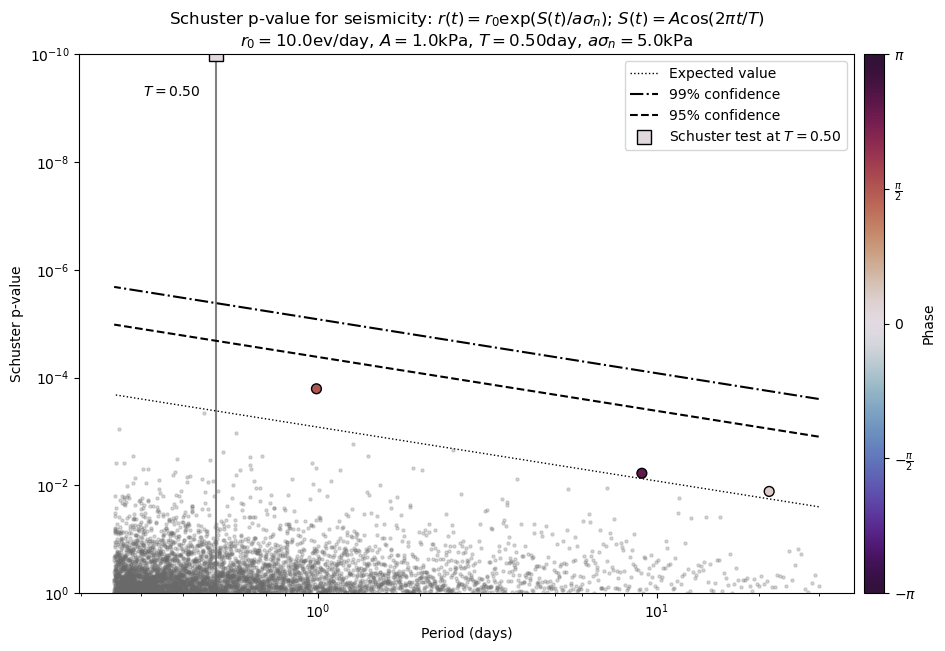

In [42]:
# plot the results of the Schuster spectrum
p_min = 1.e-10

fig, ax = seistides.schuster.plot_schuster_spectrum(log_p, test_periods, obs_duration, trajectory_phase=trajectory_phase, figsize=(10, 7), p_min=p_min)

ax.axvline(T, color="grey", zorder=0.5)
ax.text(0.9 * T, 5. * p_min, r"$T=$"f"{T:.2f}", ha="right", va="center")
_log_p, _phase = seistides.schuster.schuster_test(event_times, T)
ax.plot(T, max(p_min, np.exp(_log_p)), marker="s", markersize=10, markeredgecolor="k", ls="", color=scalar_map_phase.to_rgba(_phase), label=r"Schuster test at $T=0.50$")

ax.legend()

title = r"$r(t) = r_0 \exp(S(t) / a \sigma_n)$; $S(t) = A \cos(2\pi t / T)$""\n"r"$r_0=$"f"{R_0:.1f}ev/day, "r"$A=$"f"{AMP/1.e3:.1f}kPa, "r"$T=$"f"{T:.2f}day, "r"$a \sigma_n=$"f"{A_SIGMA_N/1.e3:.1f}kPa"
ax.set_title(r"Schuster p-value for seismicity: " + title)

In [43]:
# for format in ["pdf", "svg"]:
#     fig.savefig(
#         f"schuster_sinusoid.{format}", format=format, dpi=250, bbox_inches="tight"
#     )

## Test 2: Tide-like forcing

Now, we will the modeled tidal stresses for a realistic $S(t)$.

### Generate the synthetic catalog

In [118]:
# --------------------------
#    experiment parameters
# --------------------------
R_0 = 1. # in number of events per day (try R_0=1 to challenge the measurement methods)
A_SIGMA_N = 5.e3
START_TIME = pd.Timestamp("2016-01-01")
END_TIME = pd.Timestamp("2019-07-03")
BUFFER = pd.Timedelta(days=30)

In [119]:
TIDAL_STRESS_FILENAME = f"{TIDAL_STRESS_BASENAME}_{REGION}.h5"

STRESS_FIELDS = [
    "shear_stress",
    "normal_stress",
    "coulomb_stress",
]

tidal_stress = seistides.utils.load_tidal_stress(
    os.path.join(PATH_DATA, TIDAL_STRESS_FILENAME),
    fields=STRESS_FIELDS,
    rate=False,
    t_end="2024-01-01"
    )

In [120]:
# down-sample the tidal stress time series to speed up the following test
NEW_SAMPLING = "0.25h"
forcing = tidal_stress.loc[
    (tidal_stress.index > START_TIME - BUFFER) & (tidal_stress.index < END_TIME + BUFFER), ["coulomb_stress"]
    ].copy()
forcing = forcing.resample(NEW_SAMPLING).mean()

# --------------
# the following is to simulate a lagged response
PHASE_LAG = -np.pi / 2.
mean = forcing["coulomb_stress"].mean()
fft = np.fft.rfft((forcing["coulomb_stress"].values - mean))

phase_shift = np.exp(-1j * PHASE_LAG) * np.ones_like(fft)
phase_shift[0] = 1.0  # keep DC unshifted
if len(forcing) % 2 == 0:
    phase_shift[-1] = 1.0  # Keep Nyquist unshifted
fft_dephased = fft * phase_shift
forcing_dephased = np.fft.irfft(fft_dephased) + mean

trim_buffer = (forcing.index >= START_TIME) & (forcing.index <= END_TIME)
forcing = forcing.loc[trim_buffer, "coulomb_stress"]
forcing_dephased = forcing_dephased[trim_buffer]
# --------------

time = forcing.index
time = (time - time[0]).total_seconds() / (24. * 3600.)
dt = time[1] - time[0]
forcing = forcing.values

# --------------
#    use the original tidal stress time series
rates = R_0 * rs_modulation(forcing, a_sigma_n=A_SIGMA_N)
# --------------
#    use the dephased tidal stress time series
# rates = R_0 * rs_modulation(forcing_dephased, a_sigma_n=A_SIGMA_N)

Text(0.5, 0, 'Dimensionless time')

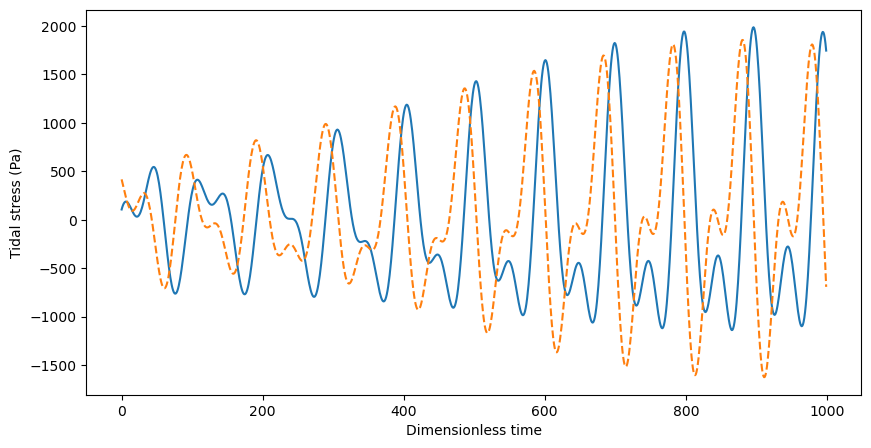

In [121]:
fig, ax = plt.subplots(num="original_vs_dephased_time_series", figsize=(10, 5))

ax.plot(forcing[:1000])
ax.plot(forcing_dephased[:1000], ls="--")
ax.set_ylabel("Tidal stress (Pa)")
ax.set_xlabel("Dimensionless time")

In [122]:
# generate a stochastic realization of the nonhomohegeneous poisson process
np.random.seed(42)
event_counts = generate_nhpp_counts(rates, dt)
# convert the event count into actual event times
event_times = counts_to_timestamps(event_counts, dt)

In [123]:
##
# make sure that catalog follows expected seismicity vs forcing relationship
bins = np.linspace(forcing.min(), forcing.max(), 10)
bin_membership = np.digitize(forcing, bins=bins)

forcing_midbins = (bins[1:] + bins[:-1]) / 2.
mean_ec = np.zeros(len(forcing_midbins))

for i in range(1, len(bins)):
    sel = bin_membership == i
    forcing_bin = (bins[i-1] + bins[i]) / 2.
    mean_ec[i - 1] = np.mean(event_counts[sel])

ref = np.abs(forcing_midbins - 0.).argmin()


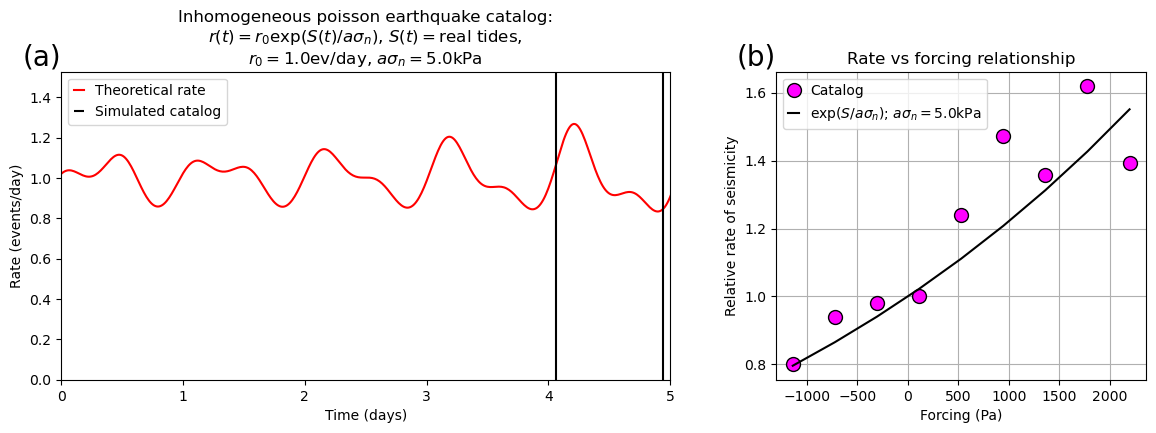

In [124]:
fig = plt.figure("synthetic_catalog", figsize=(14, 4))
gs = fig.add_gridspec(ncols=5, wspace=0.80)
ax1 = fig.add_subplot(gs[:3])
ax1.plot(time, rates, 'r-', label=r'Theoretical rate')
ax1.eventplot(event_times, lineoffsets=0., linelengths=2. * 1.25 * np.exp(AMP / A_SIGMA_N) * R_0, color="k", label="Simulated catalog")
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Rate (events/day)')
title = r"$r(t) = r_0 \exp(S(t) / a \sigma_n)$, $S(t)=$real tides, ""\n"r"$r_0=$"f"{R_0:.1f}ev/day, "r"$a \sigma_n=$"f"{A_SIGMA_N/1.e3:.1f}kPa"
ax1.set_title('Inhomogeneous poisson earthquake catalog:\n' + title)
ax1.set_xlim(0, 5)
ax1.set_ylim(0., 1.25 * np.exp(AMP / A_SIGMA_N) * R_0)

ax2 = fig.add_subplot(gs[3:])
ax2.plot(forcing_midbins, mean_ec / mean_ec[ref], marker="o", ls="", markeredgecolor="k", markersize=10, color="magenta", label="Catalog")
ax2.plot(forcing_midbins, rs_modulation(forcing_midbins, a_sigma_n=A_SIGMA_N), color="k", label=r"$\exp(S / a \sigma_n)$; $a \sigma_n=$"f"{A_SIGMA_N/1.e3:.1f}kPa")
ax2.set_xlabel("Forcing (Pa)")
ax2.set_ylabel("Relative rate of seismicity")
ax2.grid()
ax2.set_title("Rate vs forcing relationship")

for i, ax in enumerate([ax1, ax2]):
    ax.legend(handlelength=0.75)
    ax.text(
        0., 1.0,
        f"({string.ascii_lowercase[i]})",
        va="bottom",
        fontsize=20,
        ha="right",
        transform=ax.transAxes,
    )

In [125]:
# for format in ["pdf", "svg"]:
#     fig.savefig(
#         fig.get_label() + f".{format}", format=format, dpi=250, bbox_inches="tight"
#     )

### Schuster spectrum

Here, we will see that the Schuster spectrum is seriously challenged by the non-harmonic nature of real tides when the background rate of seismicity is low (try $R_0=1$).

In [126]:
fft = np.fft.rfft((forcing - forcing.mean())  * tukey(len(forcing)))
freq = np.fft.rfftfreq(len(forcing), d=dt)
period = 1. / freq[1:]
fft_vs_period_interpolator = interp1d(period, fft[1:])

In [127]:
# --------------------------
# Schuster spectrum parameters
# --------------------------
T_MIN_DAY = 0.25 # shortest period in days
T_MAX_DAY = 30. # longest period in days

log_p, trajectory_phase, test_periods = seistides.schuster.compute_schuster_spectrum(
    event_times, T_MIN_DAY, T_MAX_DAY, fft_vs_period_interpolator=fft_vs_period_interpolator
)
obs_duration = (event_times.max() - event_times.min())

Text(0.5, 1.0, 'Schuster p-values')

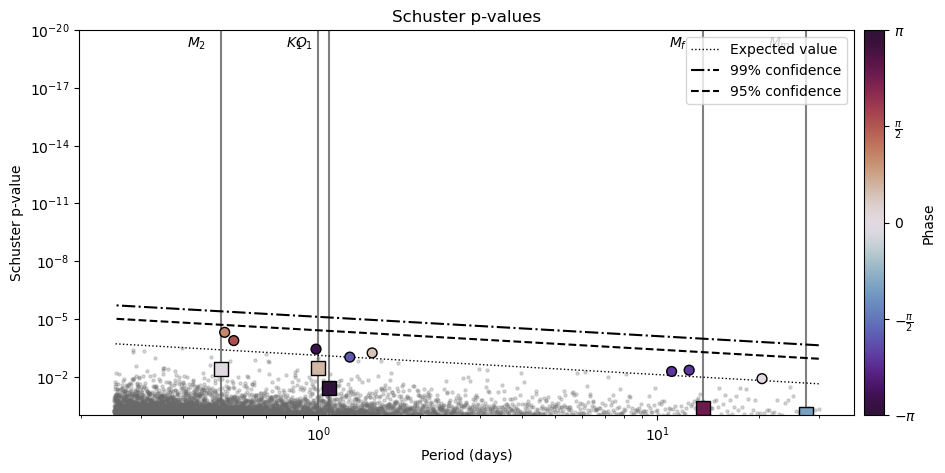

In [128]:
# plot the results of the Schuster spectrum
p_min = 1.0e-20

fig, ax = seistides.schuster.plot_schuster_spectrum(
    log_p,
    test_periods,
    obs_duration,
    trajectory_phase=trajectory_phase,
    figsize=(10, 5),
    p_min=p_min,
)

for tidal_period, tidal_constituent in zip(
    [12.42, 23.93447213, 25.81933871], [r"$M_2$", r"$K_1$", r"$O_1$"]
):
    tidal_period_days = tidal_period / 24.0
    ax.axvline(tidal_period_days, color="grey", zorder=0.5)
    ax.text(
        0.9 * tidal_period_days, 5.0 * p_min, tidal_constituent, ha="right", va="center"
    )
    _log_p, _phase = seistides.schuster.schuster_test(
        event_times,
        tidal_period_days,
        fft_vs_period_interpolator=fft_vs_period_interpolator,
    )
    ax.plot(
        tidal_period_days,
        max(p_min, np.exp(_log_p)),
        marker="s",
        markersize=10,
        markeredgecolor="k",
        color=scalar_map_phase.to_rgba(_phase),
    )

for tidal_period_days, tidal_constituent in zip(
    [13.660830779, 27.554631896], [r"$M_f$", r"$M_m$"]
):
    ax.axvline(tidal_period_days, color="grey", zorder=0.5)
    ax.text(
        0.9 * tidal_period_days, 5.0 * p_min, tidal_constituent, ha="right", va="center"
    )
    _log_p, _phase = seistides.schuster.schuster_test(
        event_times,
        tidal_period_days,
        fft_vs_period_interpolator=fft_vs_period_interpolator,
    )
    ax.plot(
        tidal_period_days,
        max(p_min, np.exp(_log_p)),
        marker="s",
        markersize=10,
        markeredgecolor="k",
        color=scalar_map_phase.to_rgba(_phase),
    )

title = (
    r"$r(t) = r_0 \exp(S(t) / a \sigma_n)$; $S(t)=$real tides"
    "\n"
    r"$r_0=$"
    f"{R_0:.1f}ev/day, "
    r"$a \sigma_n=$"
    f"{A_SIGMA_N/1.e3:.1f}kPa"
)
ax.set_title(r"Schuster p-value for seismicity: " + title)

ax.set_title("Schuster p-values")

In [129]:
# for format in ["pdf", "svg"]:
#     fig.savefig(
#         f"schuster_real_tides.{format}", format=format, dpi=250, bbox_inches="tight"
#     )

### `seistides` multiple windows

This is the methodology applied in Beaucé et al. (2026, BSSA).

In [130]:
# the methodology requires a finer temporal sampling to accurately calculate the rate of seismicity at different phases
forcing = tidal_stress.loc[
    (tidal_stress.index > START_TIME - BUFFER) & (tidal_stress.index < END_TIME + BUFFER), ["coulomb_stress"]
    ].copy()
dt = forcing.index[1] - forcing.index[0]
UPSAMPLING_FACTOR = 10
forcing = forcing.resample(dt / UPSAMPLING_FACTOR).interpolate("linear")
forcing["coulomb_stress"] = resample_poly(forcing["coulomb_stress"].values[::int(UPSAMPLING_FACTOR)], UPSAMPLING_FACTOR, 1, axis=0)[:len(forcing)]

In [131]:
# the instantaneous phase comes from the analytical signal, which is given by scipy's hilbert function
analytical_signal = hilbert(forcing["coulomb_stress"])
forcing["instantaneous_phase_coulomb"] = np.angle(analytical_signal, deg=True)

In [132]:
# methodology parameters (use the same as in the 2026 study)
SHORT_WINDOW_DAYS = 3 * 30
OVERLAP = 0.80
NUM_SHORT_WINDOWS = 64

large_window_dur = NUM_SHORT_WINDOWS*(1.-OVERLAP)*SHORT_WINDOW_DAYS + OVERLAP*SHORT_WINDOW_DAYS
print(f"Large window duration: {large_window_dur:.2f} days / {large_window_dur/365.:.2f} years")
WINDOW_TYPE = "backward"

PHASE_BINS = {
    "instantaneous_phase_coulomb": np.linspace(-180., +180., 26)
}

window_duration = pd.Timedelta(days=large_window_dur)

# format event timings into a pandas.DataFrame
_cat = pd.DataFrame(
    columns=["event_timing_sec"],
    data=forcing.index[0].timestamp() + event_times * 24. * 3600.
)
_cat["origin_time"] = pd.to_datetime(_cat["event_timing_sec"].values, unit="s")
_cat = _cat[
    (_cat["origin_time"] >= START_TIME) & (_cat["origin_time"] <= END_TIME)
]

seismicity_modulation = seistides.modulation.ModulationmeterMultiWindowForcingTimeBins(
    short_window_days=SHORT_WINDOW_DAYS,
    overlap=OVERLAP,
    num_short_windows=NUM_SHORT_WINDOWS,
    catalog=_cat,
    forcing=forcing,
    forcing_bins=PHASE_BINS,
    window_type=WINDOW_TYPE
)
seismicity_modulation.build_forcingtime_bins()
seismicity_modulation.count_events_in_forcingtime_bins()
seismicity_modulation.forcingtime_bins

Large window duration: 1224.00 days / 3.35 years


{'instantaneous_phase_coulomb':       forcing_bin_membership  forcingtime_bin_starttime_sec  forcingtime_bin_duration_sec  forcingtime_bin_count
 0                         20                   1.449015e+09                        7740.0                    0.0
 1                         21                   1.449022e+09                        4170.0                    0.0
 2                         22                   1.449027e+09                        2310.0                    0.0
 3                         23                   1.449029e+09                        1560.0                    0.0
 4                         24                   1.449030e+09                        1170.0                    0.0
 ...                      ...                            ...                           ...                    ...
 47191                     14                   1.564694e+09                        2490.0                    0.0
 47192                     15                   1.564696e

In [133]:
# methodology parameters (use the same as in the 2026 study)
AGGREGATE = "median"
AGGREGATE_KWARGS = {
    # "reconstruction_factor": 0.66,
    # "max_singular_values": 5,
}
NUM_RESAMPLINGS = 50
MODEL = "exp"
if MODEL == "exp":
    OBJ_FUNCTION = "l2"
else:
    OBJ_FUNCTION = "negative-log-likelihood"

RATE_ESTIMATE_KWARGS = {
    "num_std_cutoff": 0.0,
    "num_bootstraps": 0,
    "bin_extension": 3,
    "cyclic_bins": True,
}
WIENER_FILTERING_KWARGS = {
    "mysize": [3, 19],
}
SVD_FILTERING_KWARGS = {
    "reconstruction_factor": 0.66,
}

t_end = forcing.index[-1]

seismicity_modulation.measure_modulation(
    t_end,
    "instantaneous_phase_coulomb",
    progress=False,
    window_type=seismicity_modulation.window_type,
    min_num_events_in_short_window=10,
    num_bootstrap_for_errors=NUM_RESAMPLINGS,
    aggregate=AGGREGATE,
    aggregate_kwargs=AGGREGATE_KWARGS,
    rate_estimate_kwargs=RATE_ESTIMATE_KWARGS,
    # wiener_filtering_kwargs=WIENER_FILTERING_KWARGS,
    svd_filtering_kwargs=SVD_FILTERING_KWARGS,
)
if ("instantaneous_phase_coulomb" in seismicity_modulation.modulation) and (
    t_end in seismicity_modulation.modulation["instantaneous_phase_coulomb"]
):
    # fit ratio
    seismicity_modulation.fit_modulation(
        seistides.models.fit_relative_rate_vs_phase,
        t_end,
        "instantaneous_phase_coulomb",
        num_resamplings=NUM_RESAMPLINGS,
        objective=OBJ_FUNCTION,
        model=MODEL,
        quantity="relative_rate",
        invert_norm=False
    )
    seismicity_modulation.evaluate_goodnessoffit(
        t_end, "instantaneous_phase_coulomb", model_name="model1", quantity="relative_rate",
    )

<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_251363/38442702.py:9: SyntaxWarning: invalid escape sequence '\p'
  label =r"$\exp( \alpha \cos (\phi - \phi_0) )$""\n"r"$\alpha=$"f"{_model['parameters']['alpha']:.2f}, $\phi_0=$"f"{_model['parameters']['phi']:.2f}rad"


Text(0.5, 0, 'Tidal instantaneous phase, $\\phi_I$ (rad)')

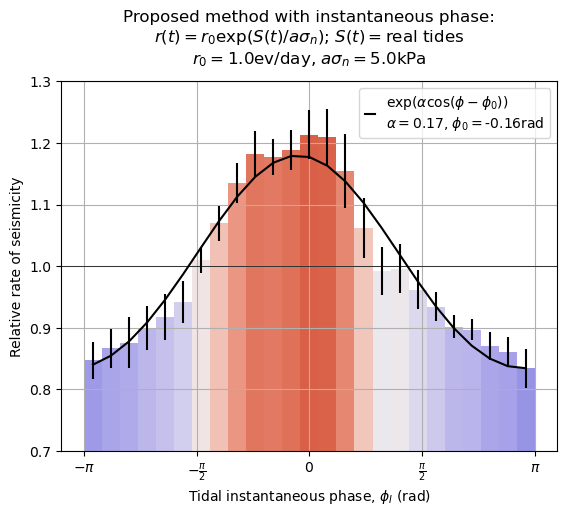

In [134]:
fig = seismicity_modulation.plot_modulation(
    "instantaneous_phase_coulomb", t_end, ymin=0.70, ymax=1.30, cmap=cc.cm.coolwarm
)
ax = fig.get_axes()[0]

_model = seismicity_modulation.model["instantaneous_phase_coulomb"][t_end]["model1"]
_midbins = seismicity_modulation.modulation["instantaneous_phase_coulomb"][t_end]["midbins"]
fit = _model["func"](np.deg2rad(_midbins))
label =r"$\exp( \alpha \cos (\phi - \phi_0) )$""\n"r"$\alpha=$"f"{_model['parameters']['alpha']:.2f}, $\phi_0=$"f"{_model['parameters']['phi']:.2f}rad"
ax.plot(_midbins, fit, color="k", label=label)
ax.legend(handlelength=0.75)
title = r"$r(t) = r_0 \exp(S(t) / a \sigma_n)$; $S(t)=$real tides""\n"r"$r_0=$"f"{R_0:.1f}ev/day, "r"$a \sigma_n=$"f"{A_SIGMA_N/1.e3:.1f}kPa"
ax.set_title("Proposed method with instantaneous phase:\n"+title, pad=13)
ax.set_xlabel(r"Tidal instantaneous phase, $\phi_I$ (rad)")

In [135]:
# for format in ["pdf", "svg"]:
#     fig.savefig(
#         f"my_method_real_tides.{format}", format=format, dpi=250, bbox_inches="tight"
#     )

### `seistides` single window

Now, let's see what happens if we use a single long window instead of our multi-window single-extraction procedure (again, try this in more challenging conditions with $R_0=1$).

In [136]:
# methodology parameters
WINDOW_DAYS = 1223

large_window_dur = NUM_SHORT_WINDOWS*(1.-OVERLAP)*SHORT_WINDOW_DAYS + OVERLAP*SHORT_WINDOW_DAYS
print(f"Large window duration: {large_window_dur:.2f} days / {large_window_dur/365.:.2f} years")
WINDOW_TYPE = "backward"

PHASE_BINS = {
    "instantaneous_phase_coulomb": np.linspace(-180., +180., 26)
}

window_duration = pd.Timedelta(days=large_window_dur)

# format event timings into a pandas.DataFrame
_cat = pd.DataFrame(
    columns=["event_timing_sec"],
    data=forcing.index[0].timestamp() + event_times * 24. * 3600.
)
_cat["origin_time"] = pd.to_datetime(_cat["event_timing_sec"].values, unit="s")
_cat = _cat[
    (_cat["origin_time"] >= START_TIME) & (_cat["origin_time"] <= END_TIME)
]

seismicity_modulation = seistides.modulation.ModulationmeterForcingTimeBins(
    window_duration_days=WINDOW_DAYS,
    catalog=_cat,
    forcing=forcing,
    forcing_bins=PHASE_BINS,
    window_type=WINDOW_TYPE
)
seismicity_modulation.build_forcingtime_bins(first_order_correction=False)
seismicity_modulation.count_events_in_forcingtime_bins()
seismicity_modulation.forcingtime_bins

Large window duration: 1224.00 days / 3.35 years


{'instantaneous_phase_coulomb':       forcing_bin_membership  forcingtime_bin_starttime_sec  forcingtime_bin_duration_sec  forcingtime_bin_count
 0                         20                   1.449015e+09                        7740.0                    0.0
 1                         21                   1.449022e+09                        4170.0                    0.0
 2                         22                   1.449027e+09                        2310.0                    0.0
 3                         23                   1.449029e+09                        1560.0                    0.0
 4                         24                   1.449030e+09                        1170.0                    0.0
 ...                      ...                            ...                           ...                    ...
 47191                     14                   1.564694e+09                        2490.0                    0.0
 47192                     15                   1.564696e

In [137]:
# methodology parameters
AGGREGATE = "median"
AGGREGATE_KWARGS = {
    # "reconstruction_factor": 0.66,
    # "max_singular_values": 5,
}
NUM_RESAMPLINGS = 50
MODEL = "exp"
if MODEL == "exp":
    OBJ_FUNCTION = "l2"
else:
    OBJ_FUNCTION = "negative-log-likelihood"

RATE_ESTIMATE_KWARGS = {
    "num_std_cutoff": 0.0,
    "num_bootstraps": 0,
    "bin_extension": 3,
    "cyclic_bins": True,
}
WIENER_FILTERING_KWARGS = {
    "mysize": [3, 19],
}
SVD_FILTERING_KWARGS = {
    "reconstruction_factor": 0.66,
}

t_end = END_TIME

seismicity_modulation.measure_modulation(
    t_end,
    "instantaneous_phase_coulomb",
    progress=False,
    window_type=seismicity_modulation.window_type,
    min_num_events_in_short_window=10,
    num_bootstrap_for_errors=NUM_RESAMPLINGS,
    rate_estimate_kwargs=RATE_ESTIMATE_KWARGS,
)
if ("instantaneous_phase_coulomb" in seismicity_modulation.modulation) and (
    t_end in seismicity_modulation.modulation["instantaneous_phase_coulomb"]
):
    # fit ratio
    seismicity_modulation.fit_modulation(
        seistides.models.fit_relative_rate_vs_phase,
        t_end,
        "instantaneous_phase_coulomb",
        num_resamplings=NUM_RESAMPLINGS,
        objective=OBJ_FUNCTION,
        model=MODEL,
        quantity="relative_rate",
        invert_norm=False
    )
    seismicity_modulation.evaluate_goodnessoffit(
        t_end, "instantaneous_phase_coulomb", model_name="model1", quantity="relative_rate",
    )

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_251363/1964161084.py:11: SyntaxWarning: invalid escape sequence '\p'
  label =r"$\exp( \alpha \cos (\phi - \phi_0) )$""\n"r"$\alpha=$"f"{_model['parameters']['alpha']:.2f}, $\phi_0=$"f"{_model['parameters']['phi']:.2f}rad"


Text(0.5, 0, 'Tidal instantaneous phase, $\\phi_I$ (rad)')

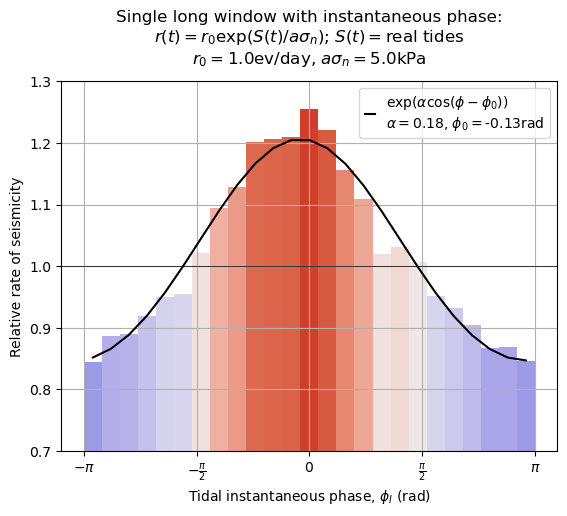

In [138]:
# here, the figure doesn't show uncertainties because the single window procedure does not
# provide information on uncertainties
fig = seismicity_modulation.plot_modulation(
    "instantaneous_phase_coulomb", t_end, ymin=0.70, ymax=1.30, cmap=cc.cm.coolwarm
)
ax = fig.get_axes()[0]

_model = seismicity_modulation.model["instantaneous_phase_coulomb"][t_end]["model1"]
_midbins = seismicity_modulation.modulation["instantaneous_phase_coulomb"][t_end]["midbins"]
fit = _model["func"](np.deg2rad(_midbins))
label =r"$\exp( \alpha \cos (\phi - \phi_0) )$""\n"r"$\alpha=$"f"{_model['parameters']['alpha']:.2f}, $\phi_0=$"f"{_model['parameters']['phi']:.2f}rad"
ax.plot(_midbins, fit, color="k", label=label)
ax.legend(handlelength=0.75)
title = r"$r(t) = r_0 \exp(S(t) / a \sigma_n)$; $S(t)=$real tides""\n"r"$r_0=$"f"{R_0:.1f}ev/day, "r"$a \sigma_n=$"f"{A_SIGMA_N/1.e3:.1f}kPa"
ax.set_title("Single long window with instantaneous phase:\n"+title, pad=13)
ax.set_xlabel(r"Tidal instantaneous phase, $\phi_I$ (rad)")

In [139]:
# for format in ["pdf", "svg"]:
#     fig.savefig(
#         f"single_window_inst_phase_real_tides.{format}", format=format, dpi=250, bbox_inches="tight"
#     )

### Linear phase multiple windows

What happens now if we use the linear phase instead of the instantaneous phase?

In [140]:
def compute_linear_phase(stress_amplitudes, times, dt_sec=None):
    """Compute the linear phase of a tidal stress time series.

    Parameters
    ----------
    stress_amplitudes : numpy.ndarray
        The tidal stress time series.
    times : numpy.ndarray
        The times of the tidal stress time series.
    dt_sec : float, optional
        If not None, this is used to impose a 30-min minimum distance between the detected local maxima
        and minima (which is fine given the shortest significant period in the tides is ~12hours).
    """
    from scipy.signal import find_peaks
    from scipy.interpolate import interp1d

    if dt_sec is not None:
        min_peak_distance = int(30. * 60. / dt_sec)
    else:
        min_peak_distance = 1

    peak_indexes, _ = find_peaks(stress_amplitudes, distance=min_peak_distance, width=min_peak_distance)
    times_0 = times[peak_indexes]
    trough_indexes, _ = find_peaks(-1. * stress_amplitudes, distance=min_peak_distance, width=min_peak_distance)
    times_180 = times[trough_indexes]
    eps = 1.e-6
    times_minus_180 = times_180 + eps

    ref_phases = np.hstack((np.zeros(len(times_0)), 180. * np.ones(len(times_180)), -180. * np.ones(len(times_minus_180))))
    ref_times = np.hstack((times_0, times_180, times_minus_180))

    ref_phases = ref_phases[np.argsort(ref_times)]
    ref_times = np.sort(ref_times)

    interpolator = interp1d(ref_times, ref_phases)

    linear_phases = np.zeros(len(times))
    valid = (times >= ref_times[0]) & (times <= ref_times[-1])
    linear_phases[valid] = interpolator(times[valid])
    linear_phases[~valid] = np.nan

    return linear_phases

In [141]:
# the methodology requires a finer temporal sampling to accurately calculate the rate of seismicity at different phases
forcing = tidal_stress.loc[
    (tidal_stress.index > START_TIME - BUFFER) & (tidal_stress.index < END_TIME + BUFFER), ["coulomb_stress"]
    ].copy()
dt = forcing.index[1] - forcing.index[0]
UPSAMPLING_FACTOR = 10
forcing = forcing.resample(dt / UPSAMPLING_FACTOR).interpolate("linear")
forcing["coulomb_stress"] = resample_poly(forcing["coulomb_stress"].values[::int(UPSAMPLING_FACTOR)], UPSAMPLING_FACTOR, 1, axis=0)[:len(forcing)]

In [142]:
# compute the linear phase
dt = forcing.index[1] - forcing.index[0]
forcing["linear_phase_coulomb"] = compute_linear_phase(
    forcing["coulomb_stress"].values, forcing.index.values.astype("float64") / 1.e9, dt_sec=dt.total_seconds()
)

In [143]:
# compute the instantaneous phase so that we can compare it to the linear phase
analytical_signal = hilbert(forcing["coulomb_stress"])
forcing["instantaneous_phase_coulomb"] = np.angle(analytical_signal, deg=True)

In [144]:
phase_difference = np.deg2rad(np.abs(
    np.minimum(
    np.angle(np.exp(1j * (forcing["instantaneous_phase_coulomb"].values - forcing["linear_phase_coulomb"].values))),
    np.angle(np.exp(1j * (forcing["linear_phase_coulomb"].values - forcing["instantaneous_phase_coulomb"].values))),
)
))

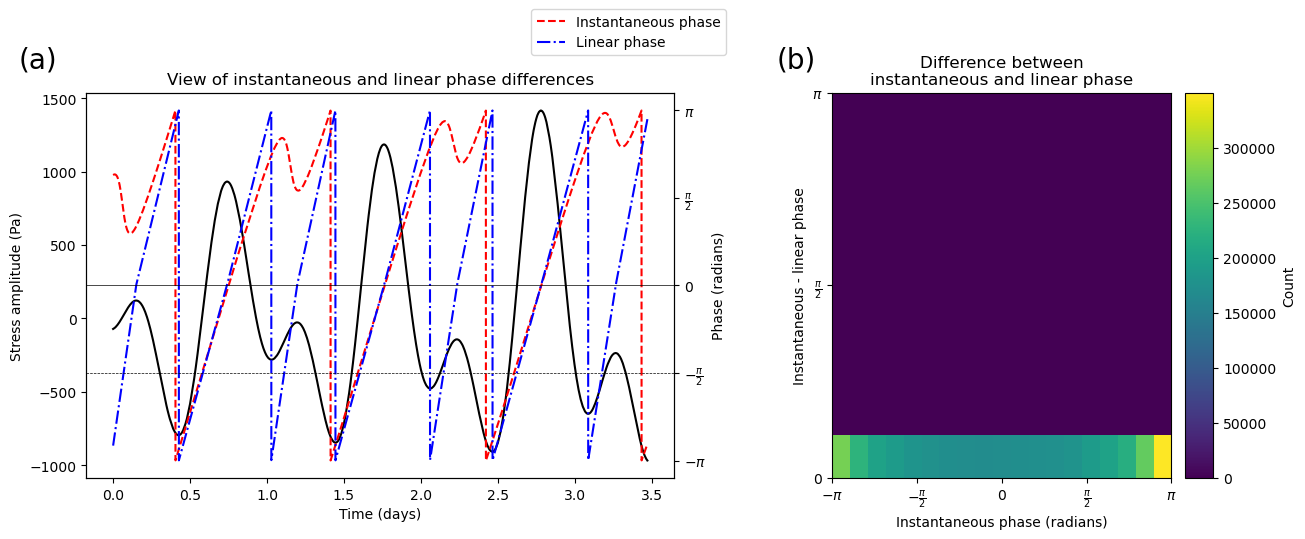

In [145]:
# how does the instantaneous phase differ from the linear phase?
# the following plot shows that weak local maxima are given a linear phase of 0
# while the instantaneous phase attributes a number closer to +/-pi,
# which seems to be a more appropriate representation of these weak values
# in practice, using the linear phase or the instantaneous phase doesn't seem to matter much
n0 = 10000
n = 10000

_time = forcing.index[n0:n0+n]
_time = (_time - _time[0]).total_seconds() / (24. * 3600.)

fig = plt.figure("instantaneous_vs_linear_phase", figsize=(14, 5))
gs = fig.add_gridspec(ncols=5, wspace=1.75)

ax1 = fig.add_subplot(gs[:3])
axb = ax1.twinx()

ax1.plot(_time, forcing["coulomb_stress"].values[n0:n0+n], color="k")
axb.plot(_time, np.deg2rad(forcing["instantaneous_phase_coulomb"].values[n0:n0+n]), color="r", ls="--", label="Instantaneous phase")
axb.plot(_time, np.deg2rad(forcing["linear_phase_coulomb"].values[n0:n0+n]), color="b", ls="-.", label="Linear phase")

axb.axhline(0., color="k", lw=0.5)
axb.axhline(-np.pi/2., color="k", ls="--", lw=0.5)
axb.set_ylabel("Phase (radians)")
ax1.set_ylabel("Stress amplitude (Pa)")
ax1.set_xlabel("Time (days)")
ytick_loc = [-np.pi, -np.pi/2., 0., np.pi/2., np.pi]
ytick_lab = [r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"]
axb.set_yticks(ytick_loc)
axb.set_yticklabels(ytick_lab)
axb.legend(bbox_to_anchor=(1.1, 1.08), loc="lower right")
ax1.set_title("View of instantaneous and linear phase differences")

ax2 = fig.add_subplot(gs[3:])
_bins = [np.linspace(-np.pi, np.pi, 20), np.linspace(0., np.pi, 10)]
counts, _, _ = np.histogram2d(np.deg2rad(forcing["instantaneous_phase_coulomb"].values), phase_difference, bins=_bins)
pc = ax2.pcolormesh(_bins[0], _bins[1], counts.T)#, norm=LogNorm())
# ax2.scatter(np.deg2rad(forcing["linear_phase_coulomb"].values), phase_difference, alpha=0.33, s=1, rasterized=True)
# ax2.scatter(forcing["linear_phase_coulomb"].values, np.deg2rad(forcing["instantaneous_phase_coulomb"].values), alpha=0.33, s=1, rasterized=True)
ax2.set_xticks(ytick_loc)
ax2.set_xticklabels(ytick_lab)
ax2.set_yticks(ytick_loc[2:])
ax2.set_yticklabels(ytick_lab[2:])
ax2.set_xlabel("Instantaneous phase (radians)")
ax2.set_ylabel("Instantaneous - linear phase")
ax2.set_title("Difference between\ninstantaneous and linear phase")

pos = ax2.get_position()
cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height])
plt.colorbar(pc, cax=cax, label="Count")

for i, ax in enumerate([ax1, ax2]):
    ax.text(
        -0.05, 1.05,
        f"({string.ascii_lowercase[i]})",
        va="bottom",
        fontsize=20,
        ha="right",
        transform=ax.transAxes,
    )


In [146]:
# for format in ["pdf", "svg"]:
#     fig.savefig(
#         fig.get_label() + f".{format}", format=format, dpi=250, bbox_inches="tight"
#     )

In [147]:
# methodology parameters (use the same as in the 2026 study)
SHORT_WINDOW_DAYS = 3 * 30
OVERLAP = 0.80
NUM_SHORT_WINDOWS = 64

large_window_dur = NUM_SHORT_WINDOWS*(1.-OVERLAP)*SHORT_WINDOW_DAYS + OVERLAP*SHORT_WINDOW_DAYS
print(f"Large window duration: {large_window_dur:.2f} days / {large_window_dur/365.:.2f} years")
WINDOW_TYPE = "backward"

PHASE_BINS = {
    "linear_phase_coulomb": np.linspace(-180., +180., 26)
}

window_duration = pd.Timedelta(days=large_window_dur)

# format event timings into a pandas.DataFrame
_cat = pd.DataFrame(
    columns=["event_timing_sec"],
    data=forcing.index[0].timestamp() + event_times * 24. * 3600.
)
_cat["origin_time"] = pd.to_datetime(_cat["event_timing_sec"].values, unit="s")
_cat = _cat[
    (_cat["origin_time"] >= START_TIME) & (_cat["origin_time"] <= END_TIME)
]

seismicity_modulation = seistides.modulation.ModulationmeterMultiWindowForcingTimeBins(
    short_window_days=SHORT_WINDOW_DAYS,
    overlap=OVERLAP,
    num_short_windows=NUM_SHORT_WINDOWS,
    catalog=_cat,
    forcing=forcing,
    forcing_bins=PHASE_BINS,
    window_type=WINDOW_TYPE
)
seismicity_modulation.build_forcingtime_bins(first_order_correction=False)
seismicity_modulation.count_events_in_forcingtime_bins()
seismicity_modulation.forcingtime_bins

Large window duration: 1224.00 days / 3.35 years


{'linear_phase_coulomb':       forcing_bin_membership  forcingtime_bin_starttime_sec  forcingtime_bin_duration_sec  forcingtime_bin_count
 0                         25                   1.449015e+09                        6120.0                    0.0
 1                         13                   1.449021e+09                         360.0                    0.0
 2                         14                   1.449021e+09                         660.0                    0.0
 3                         15                   1.449022e+09                         660.0                    0.0
 4                         16                   1.449022e+09                         660.0                    0.0
 ...                      ...                            ...                           ...                    ...
 63398                     10                   1.564684e+09                        2160.0                    0.0
 63399                     11                   1.564686e+09    

In [148]:
# methodology parameters (use the same as in the 2026 study)
AGGREGATE = "median"
AGGREGATE_KWARGS = {
    # "reconstruction_factor": 0.66,
    # "max_singular_values": 5,
}
NUM_RESAMPLINGS = 50
MODEL = "exp"
if MODEL == "exp":
    OBJ_FUNCTION = "l2"
else:
    OBJ_FUNCTION = "negative-log-likelihood"

RATE_ESTIMATE_KWARGS = {
    "num_std_cutoff": 0.0,
    "num_bootstraps": 0,
    "bin_extension": 3,
    "cyclic_bins": True,
}
WIENER_FILTERING_KWARGS = {
    "mysize": [3, 19],
}
SVD_FILTERING_KWARGS = {
    "reconstruction_factor": 0.66,
}

t_end = forcing.index[-1]

seismicity_modulation.measure_modulation(
    t_end,
    "linear_phase_coulomb",
    progress=False,
    window_type=seismicity_modulation.window_type,
    min_num_events_in_short_window=10,
    num_bootstrap_for_errors=NUM_RESAMPLINGS,
    aggregate=AGGREGATE,
    aggregate_kwargs=AGGREGATE_KWARGS,
    rate_estimate_kwargs=RATE_ESTIMATE_KWARGS,
    svd_filtering_kwargs=SVD_FILTERING_KWARGS,
)
if ("linear_phase_coulomb" in seismicity_modulation.modulation) and (
    t_end in seismicity_modulation.modulation["linear_phase_coulomb"]
):
    # fit ratio
    seismicity_modulation.fit_modulation(
        seistides.models.fit_relative_rate_vs_phase,
        t_end,
        "linear_phase_coulomb",
        num_resamplings=NUM_RESAMPLINGS,
        objective=OBJ_FUNCTION,
        model=MODEL,
        quantity="relative_rate",
        invert_norm=False
    )
    seismicity_modulation.evaluate_goodnessoffit(
        t_end, "linear_phase_coulomb", model_name="model1", quantity="relative_rate",
    )

<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_251363/122991528.py:9: SyntaxWarning: invalid escape sequence '\p'
  label =r"$\exp( \alpha \cos (\phi - \phi_0) )$""\n"r"$\alpha=$"f"{_model['parameters']['alpha']:.2f}, $\phi_0=$"f"{_model['parameters']['phi']:.2f}rad"


Text(0.5, 0, 'Tidal linear phase, $\\phi_L$ (rad)')

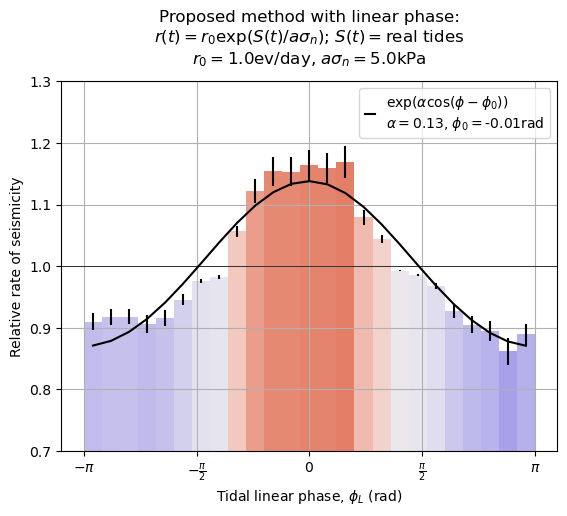

In [149]:
fig = seismicity_modulation.plot_modulation(
    "linear_phase_coulomb", t_end, ymin=0.70, ymax=1.30, cmap=cc.cm.coolwarm
)
ax = fig.get_axes()[0]

_model = seismicity_modulation.model["linear_phase_coulomb"][t_end]["model1"]
_midbins = seismicity_modulation.modulation["linear_phase_coulomb"][t_end]["midbins"]
fit = _model["func"](np.deg2rad(_midbins))
label =r"$\exp( \alpha \cos (\phi - \phi_0) )$""\n"r"$\alpha=$"f"{_model['parameters']['alpha']:.2f}, $\phi_0=$"f"{_model['parameters']['phi']:.2f}rad"
ax.plot(_midbins, fit, color="k", label=label)
ax.legend(handlelength=0.75)
title = r"$r(t) = r_0 \exp(S(t) / a \sigma_n)$; $S(t)=$real tides""\n"r"$r_0=$"f"{R_0:.1f}ev/day, "r"$a \sigma_n=$"f"{A_SIGMA_N/1.e3:.1f}kPa"
ax.set_title("Proposed method with linear phase:\n"+title, pad=13)
ax.set_xlabel(r"Tidal linear phase, $\phi_L$ (rad)")

In [150]:
# for format in ["pdf", "svg"]:
#     fig.savefig(
#         f"my_method_linear_phase_real_tides.{format}", format=format, dpi=250, bbox_inches="tight"
#     )

### Linear phase single window

Several studies have used a methodology involving the linear phase, a single-window estimation and non-overlapping phase bins. Let's see what we get with this approach.

In [151]:
WINDOW_DAYS = 1223

large_window_dur = NUM_SHORT_WINDOWS*(1.-OVERLAP)*SHORT_WINDOW_DAYS + OVERLAP*SHORT_WINDOW_DAYS
print(f"Large window duration: {large_window_dur:.2f} days / {large_window_dur/365.:.2f} years")
WINDOW_TYPE = "backward"

PHASE_BINS = {
    "linear_phase_coulomb": np.linspace(-180., +180., 26)
}

window_duration = pd.Timedelta(days=large_window_dur)

# format event timings into a pandas.DataFrame
_cat = pd.DataFrame(
    columns=["event_timing_sec"],
    data=forcing.index[0].timestamp() + event_times * 24. * 3600.
)
_cat["origin_time"] = pd.to_datetime(_cat["event_timing_sec"].values, unit="s")
_cat = _cat[
    (_cat["origin_time"] >= START_TIME) & (_cat["origin_time"] <= END_TIME)
]

seismicity_modulation = seistides.modulation.ModulationmeterForcingTimeBins(
    window_duration_days=WINDOW_DAYS,
    catalog=_cat,
    forcing=forcing,
    forcing_bins=PHASE_BINS,
    window_type=WINDOW_TYPE
)
seismicity_modulation.build_forcingtime_bins(first_order_correction=False)
seismicity_modulation.count_events_in_forcingtime_bins()
seismicity_modulation.forcingtime_bins

Large window duration: 1224.00 days / 3.35 years


{'linear_phase_coulomb':       forcing_bin_membership  forcingtime_bin_starttime_sec  forcingtime_bin_duration_sec  forcingtime_bin_count
 0                         25                   1.449015e+09                        6120.0                    0.0
 1                         13                   1.449021e+09                         360.0                    0.0
 2                         14                   1.449021e+09                         660.0                    0.0
 3                         15                   1.449022e+09                         660.0                    0.0
 4                         16                   1.449022e+09                         660.0                    0.0
 ...                      ...                            ...                           ...                    ...
 63398                     10                   1.564684e+09                        2160.0                    0.0
 63399                     11                   1.564686e+09    

In [152]:
# methodology parameters 
# --------- set RATE_ESTIMATE_KWARGS['bin_extension'] to 0 for non-overlapping pahse bins
AGGREGATE = "median"
AGGREGATE_KWARGS = {
    # "reconstruction_factor": 0.66,
    # "max_singular_values": 5,
}
NUM_RESAMPLINGS = 50
MODEL = "exp"
if MODEL == "exp":
    OBJ_FUNCTION = "l2"
else:
    OBJ_FUNCTION = "negative-log-likelihood"

RATE_ESTIMATE_KWARGS = {
    "num_std_cutoff": 0.0,
    "num_bootstraps": 0,
    "bin_extension": 0,
    "cyclic_bins": True,
}
WIENER_FILTERING_KWARGS = {
    "mysize": [3, 19],
}
SVD_FILTERING_KWARGS = {
    "reconstruction_factor": 0.66,
}

t_end = END_TIME

seismicity_modulation.measure_modulation(
    t_end,
    "linear_phase_coulomb",
    progress=False,
    window_type=seismicity_modulation.window_type,
    min_num_events_in_short_window=10,
    num_bootstrap_for_errors=NUM_RESAMPLINGS,
    rate_estimate_kwargs=RATE_ESTIMATE_KWARGS,
)
if ("linear_phase_coulomb" in seismicity_modulation.modulation) and (
    t_end in seismicity_modulation.modulation["linear_phase_coulomb"]
):
    # fit ratio
    seismicity_modulation.fit_modulation(
        seistides.models.fit_relative_rate_vs_phase,
        t_end,
        "linear_phase_coulomb",
        num_resamplings=NUM_RESAMPLINGS,
        objective=OBJ_FUNCTION,
        model=MODEL,
        quantity="relative_rate",
        invert_norm=False
    )
    seismicity_modulation.evaluate_goodnessoffit(
        t_end, "linear_phase_coulomb", model_name="model1", quantity="relative_rate",
    )

<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_251363/96706507.py:9: SyntaxWarning: invalid escape sequence '\p'
  label =r"$\exp( \alpha \cos (\phi - \phi_0) )$""\n"r"$\alpha=$"f"{_model['parameters']['alpha']:.2f}, $\phi_0=$"f"{_model['parameters']['phi']:.2f}rad"


Text(0.5, 0, 'Tidal linear phase, $\\phi_L$ (rad)')

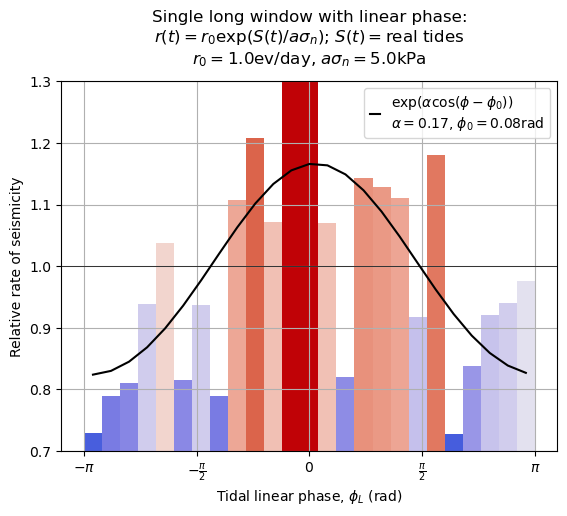

In [153]:
fig = seismicity_modulation.plot_modulation(
    "linear_phase_coulomb", t_end, ymin=0.70, ymax=1.30, cmap=cc.cm.coolwarm
)
ax = fig.get_axes()[0]

_model = seismicity_modulation.model["linear_phase_coulomb"][t_end]["model1"]
_midbins = seismicity_modulation.modulation["linear_phase_coulomb"][t_end]["midbins"]
fit = _model["func"](np.deg2rad(_midbins))
label =r"$\exp( \alpha \cos (\phi - \phi_0) )$""\n"r"$\alpha=$"f"{_model['parameters']['alpha']:.2f}, $\phi_0=$"f"{_model['parameters']['phi']:.2f}rad"
ax.plot(_midbins, fit, color="k", label=label)
ax.legend(handlelength=0.75)
title = r"$r(t) = r_0 \exp(S(t) / a \sigma_n)$; $S(t)=$real tides""\n"r"$r_0=$"f"{R_0:.1f}ev/day, "r"$a \sigma_n=$"f"{A_SIGMA_N/1.e3:.1f}kPa"
ax.set_title("Single long window with linear phase:\n"+title, pad=13)
ax.set_xlabel(r"Tidal linear phase, $\phi_L$ (rad)")

In [154]:
# for format in ["pdf", "svg"]:
#     fig.savefig(
#         f"single_window_linear_phase_real_tides.{format}", format=format, dpi=250, bbox_inches="tight"
#     )